1. Project Purpose
2. Import Libraries
3. Load Data
4. Select Variables
5. Filter the Dataset for a Clear Target
6. Clean and Prepare Variables
7. Handle Missing Data
8. Create Additional Parameters
9. Summary Statistics
10. Visualizations
11. Key Findings

# Project Purpose
This analysis explores borrower and loan characteristics within the LendingClub dataset to identify patterns associated with loan default. The objective is to prepare and understand the data in a way that supports accurate and interpretable credit risk modeling.


# Import Libraries

In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================
# This analysis relies on standard data science libraries for data manipulation
# and visualization. These libraries support efficient data handling and
# exploratory analysis.
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style for consistency
sns.set(style="whitegrid")

# Ensure all columns are visible when inspecting the dataset
pd.set_option("display.max_columns", None)

# Load Compressed Dataset

In [ ]:
# ============================================
# LOAD COMPRESSED DATASET
# ============================================
# The LendingClub dataset is provided in compressed (.gz) format.
# It is read directly into memory without manual extraction.
# A subset of observations is loaded to maintain computational efficiency
# while preserving representative data patterns.
# ============================================

file_path = "accepted_2007_to_2018Q4.csv.gz"

df = pd.read_csv(file_path, compression='gzip', nrows=200000, low_memory=False)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (200000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

# Select Relevant Variables

In [ ]:
# ============================================
# SELECT RELEVANT VARIABLES
# ============================================
# A subset of variables relevant to credit risk analysis is selected.
# This reduces dimensionality and focuses the analysis on interpretable
# and meaningful borrower and loan characteristics.
# ============================================

selected_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high",
    "term",
    "emp_length",
    "home_ownership",
    "loan_status"
]

df = df[selected_cols]

print("Shape after column selection:", df.shape)
df.head()

Shape after column selection: (200000, 9)


,loan_amnt,int_rate,annual_inc,dti,fico_range_high,term,emp_length,home_ownership,loan_status
0,3600.0,13.99,55000.0,5.91,679.0,36 months,10+ years,MORTGAGE,Fully Paid
1,24700.0,11.99,65000.0,16.06,719.0,36 months,10+ years,MORTGAGE,Fully Paid
2,20000.0,10.78,63000.0,10.78,699.0,60 months,10+ years,MORTGAGE,Fully Paid
3,35000.0,14.85,110000.0,17.06,789.0,60 months,10+ years,MORTGAGE,Current
4,10400.0,22.45,104433.0,25.37,699.0,60 months,3 years,MORTGAGE,Fully Paid


# Define Target Variable

In [ ]:
# ============================================
# DEFINE TARGET VARIABLE
# ============================================
# The dataset is filtered to include only loans with final outcomes.
# A binary default variable is created where:
# 1 = Charged Off (default)
# 0 = Fully Paid (non-default)
# ============================================

df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df["default"] = np.where(df["loan_status"] == "Charged Off", 1, 0)

print(df["loan_status"].value_counts())
print(df["default"].value_counts())

loan_status
Fully Paid     140992
Charged Off     35090
Name: count, dtype: int64
default
0    140992
1     35090
Name: count, dtype: int64


# Data Inspection

In [ ]:
# ============================================
# DATA INSPECTION
# ============================================
# The structure of the dataset is reviewed to understand data types
# and identify missing values across variables.
# ============================================

print(df.info())

missing_summary = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values by column:\n")
print(missing_summary)

<class 'pandas.core.frame.DataFrame'>
Index: 176082 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_amnt        176082 non-null  float64
 1   int_rate         176082 non-null  float64
 2   annual_inc       176082 non-null  float64
 3   dti              176080 non-null  float64
 4   fico_range_high  176082 non-null  float64
 5   term             176082 non-null  object 
 6   emp_length       164948 non-null  object 
 7   home_ownership   176082 non-null  object 
 8   loan_status      176082 non-null  object 
 9   default          176082 non-null  int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 14.8+ MB
None

Missing values by column:

emp_length         11134
dti                    2
int_rate               0
loan_amnt              0
fico_range_high        0
annual_inc             0
term                   0
home_ownership         0
loan_status            0
default  

# Clean Variable Formats

In [ ]:
# ============================================
# CLEAN VARIABLE FORMATS
# ============================================
# Variables are converted into appropriate numeric formats to support
# analysis and visualization. If variables are already numeric, they are
# preserved as-is. If they are stored as strings, the relevant numeric
# components are extracted and converted.
# ============================================

# Review current data types before conversion
print(df[["int_rate", "term"]].dtypes)

# Clean interest rate
if df["int_rate"].dtype == "object":
    df["int_rate"] = df["int_rate"].str.replace("%", "", regex=False)
    df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")
else:
    df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")

# Clean loan term
if df["term"].dtype == "object":
    df["term"] = df["term"].str.extract(r"(\d+)")
    df["term"] = pd.to_numeric(df["term"], errors="coerce")
else:
    df["term"] = pd.to_numeric(df["term"], errors="coerce")

print("Sample cleaned variables:")
print(df[["int_rate", "term"]].head())
print(df[["int_rate", "term"]].dtypes)

int_rate    float64
term         object
dtype: object
Sample cleaned variables:
   int_rate  term
0     13.99    36
1     11.99    36
2     10.78    60
4     22.45    60
5     13.44    36
int_rate    float64
term          int64
dtype: object


# Handle Missing Data

In [ ]:
# ============================================
# HANDLE MISSING DATA
# ============================================
# Missing values in numeric variables are imputed using median values
# to reduce the influence of outliers. Categorical variables are filled
# with "Unknown" to preserve observations.
# ============================================

df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())
df["dti"] = df["dti"].fillna(df["dti"].median())
df["fico_range_high"] = df["fico_range_high"].fillna(df["fico_range_high"].median())

df["emp_length"] = df["emp_length"].fillna("Unknown")
df["home_ownership"] = df["home_ownership"].fillna("Unknown")

print("Remaining missing values:\n")
print(df.isnull().sum())

Remaining missing values:

loan_amnt          0
int_rate           0
annual_inc         0
dti                0
fico_range_high    0
term               0
emp_length         0
home_ownership     0
loan_status        0
default            0
dtype: int64


# Feature Engineering

In [ ]:
# ============================================
# FEATURE ENGINEERING
# ============================================
# Additional variables are created to capture borrower leverage and
# financial stress. These engineered features may enhance interpretability
# and predictive performance in later modeling stages.
# ============================================

df["annual_inc"] = df["annual_inc"].replace(0, np.nan)
df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())

df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"]
df["high_dti_flag"] = np.where(df["dti"] > 20, 1, 0)

df[["loan_amnt", "annual_inc", "loan_to_income", "dti", "high_dti_flag"]].head()

,loan_amnt,annual_inc,loan_to_income,dti,high_dti_flag
0,3600.0,55000.0,0.065455,5.91,0
1,24700.0,65000.0,0.380000,16.06,0
2,20000.0,63000.0,0.317460,10.78,0
4,10400.0,104433.0,0.099585,25.37,1
5,11950.0,34000.0,0.351471,10.20,0


# Transformations

In [ ]:
# ============================================
# TRANSFORMATIONS
# ============================================
# Log transformations are applied to reduce skewness in financial variables
# and support improved visualization and future modeling.
# ============================================

df["log_loan_amnt"] = np.log1p(df["loan_amnt"])
df["log_annual_inc"] = np.log1p(df["annual_inc"])

df[["loan_amnt", "log_loan_amnt", "annual_inc", "log_annual_inc"]].head()

,loan_amnt,log_loan_amnt,annual_inc,log_annual_inc
0,3600.0,8.188967,55000.0,10.915107
1,24700.0,10.114599,65000.0,11.082158
2,20000.0,9.903538,63000.0,11.050906
4,10400.0,9.249657,104433.0,11.556311
5,11950.0,9.388570,34000.0,10.434145


# Summary Statistics

In [ ]:
# ============================================
# SUMMARY STATISTICS
# ============================================
# Descriptive statistics are generated to understand the distribution,
# scale, and variability of key numeric variables.
# ============================================

numeric_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high",
    "term",
    "loan_to_income"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,176082.0,14619.829398,8616.073483,1000.000000,8000.000000,12425.00,20000.000000,35000.00
int_rate,176082.0,12.109350,4.231768,5.320000,8.380000,11.99,14.650000,28.99
annual_inc,176082.0,77497.450733,81659.352799,1200.000000,46000.000000,65000.00,92000.000000,9000000.00
dti,176082.0,18.911066,9.180775,0.000000,12.310000,18.34,25.090000,999.00
fico_range_high,176082.0,698.528362,31.060901,664.000000,674.000000,689.00,714.000000,850.00
term,176082.0,41.667768,10.193303,36.000000,36.000000,36.00,36.000000,60.00
loan_to_income,176082.0,0.215019,0.115619,0.000309,0.126437,0.20,0.291667,10.00


# Loan Amount Distribution

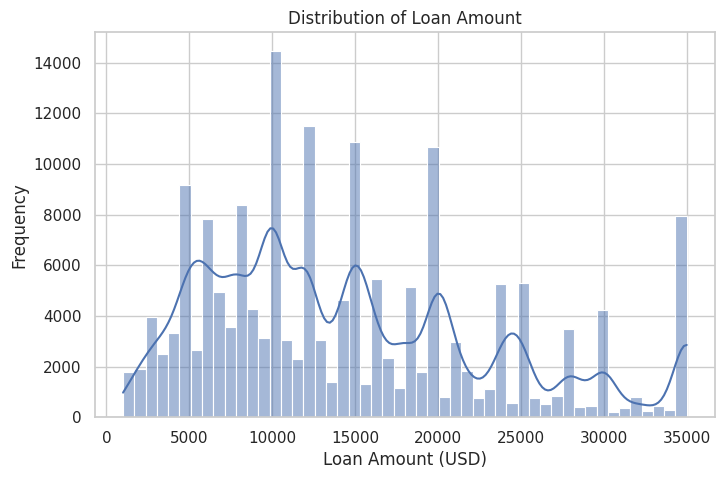

In [ ]:
# ============================================
# LOAN AMOUNT DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))
sns.histplot(df["loan_amnt"], bins=50, kde=True)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount (USD)")
plt.ylabel("Frequency")
plt.show()

# Credit Score vs Default

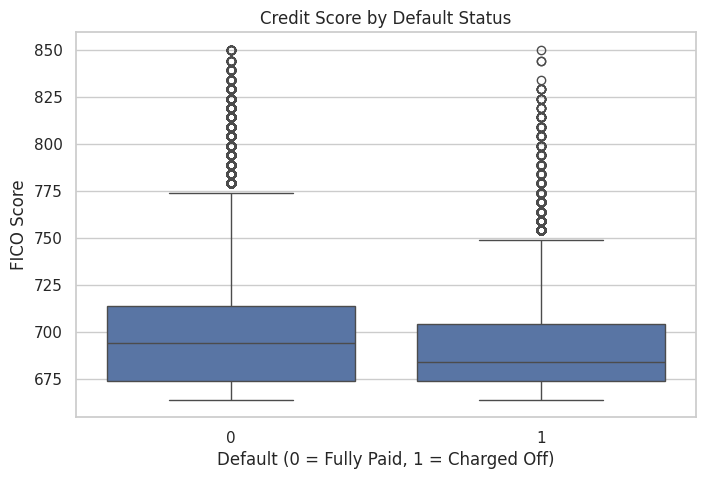

In [ ]:
# ============================================
# CREDIT SCORE VS DEFAULT
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(x="default", y="fico_range_high", data=df)
plt.title("Credit Score by Default Status")
plt.xlabel("Default (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("FICO Score")
plt.show()

# Debt-to-Income (DTI) vs Default

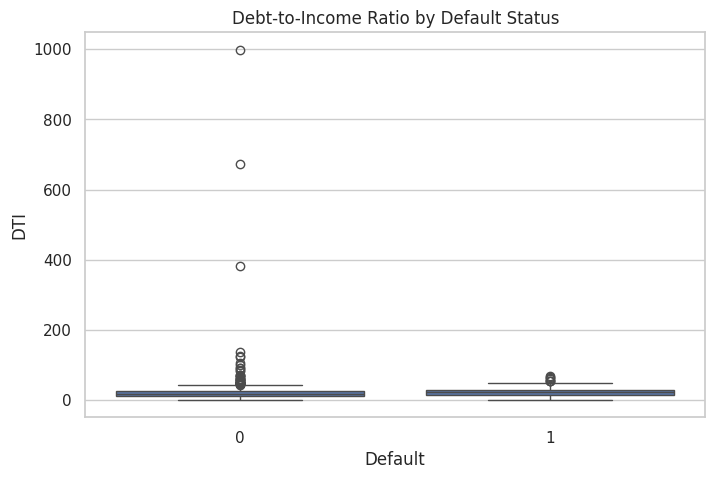

In [ ]:
# ============================================
# DTI VS DEFAULT
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(x="default", y="dti", data=df)
plt.title("Debt-to-Income Ratio by Default Status")
plt.xlabel("Default")
plt.ylabel("DTI")
plt.show()

# Interest Rate vs Default

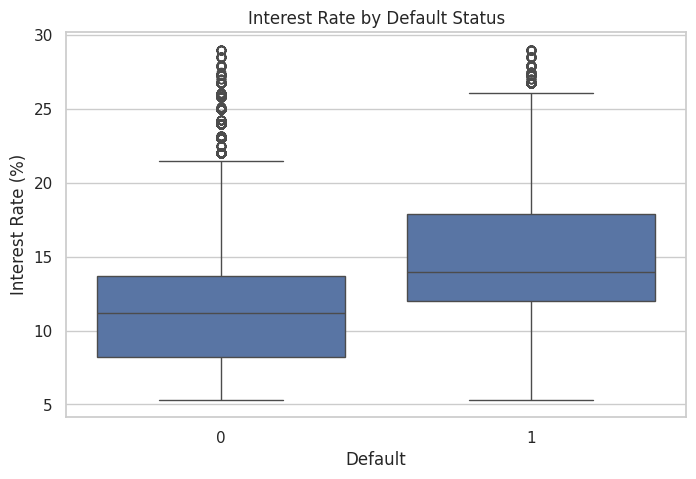

In [ ]:
# ============================================
# INTEREST RATE VS DEFAULT
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(x="default", y="int_rate", data=df)
plt.title("Interest Rate by Default Status")
plt.xlabel("Default")
plt.ylabel("Interest Rate (%)")
plt.show()

# Correlation Heatmap

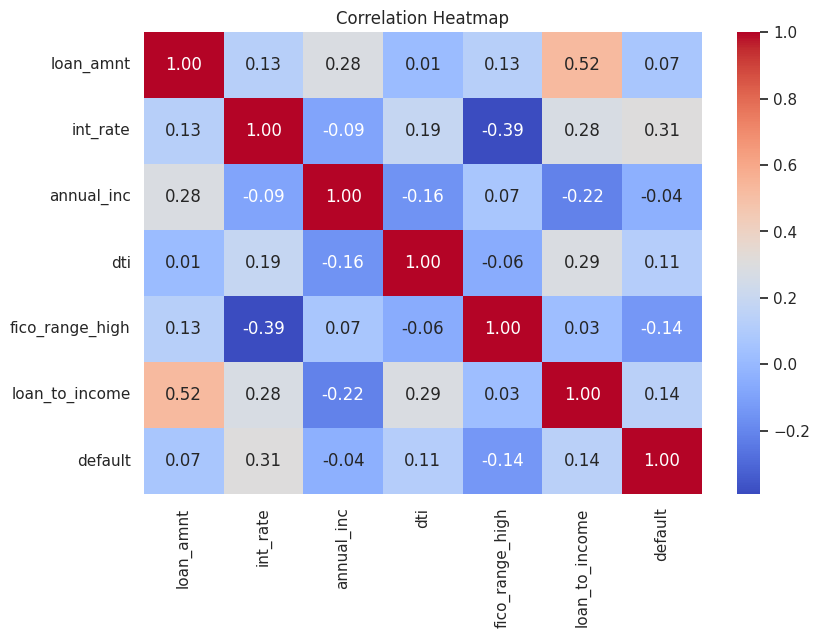

In [ ]:
# ============================================
# CORRELATION HEATMAP
# ============================================

corr_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high",
    "loan_to_income",
    "default"
]

plt.figure(figsize=(9,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Grouped Analysis

In [ ]:
# ============================================
# GROUPED ANALYSIS
# ============================================

df.groupby("default")[[
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high",
    "loan_to_income"
]].mean()

,loan_amnt,int_rate,annual_inc,dti,fico_range_high,loan_to_income
default,,,,,,
0,14333.039641,11.457144,79151.352768,18.385600,700.643583,0.206857
1,15772.153748,14.729918,70852.054449,21.022395,690.029382,0.247814
